# Eval distribution of likert scale items chosen

## Ridge plot vis
- for each experiment type
- each ridge :: one model
- density over adjusted likert scale scores (discrete)

### Ideas
- layer open/closed for each language ridge plot (flip approach and language)

### Grouped bar chart for specific construct/dataset
TODOs:
- Add likert scale item labels?
- Fix bottom and right border
- Hor line between model labels
- Color lang label

INFO 05-29 08:53:36 [__init__.py:216] Automatically detected platform cuda.


<Figure size 1500x1000 with 0 Axes>

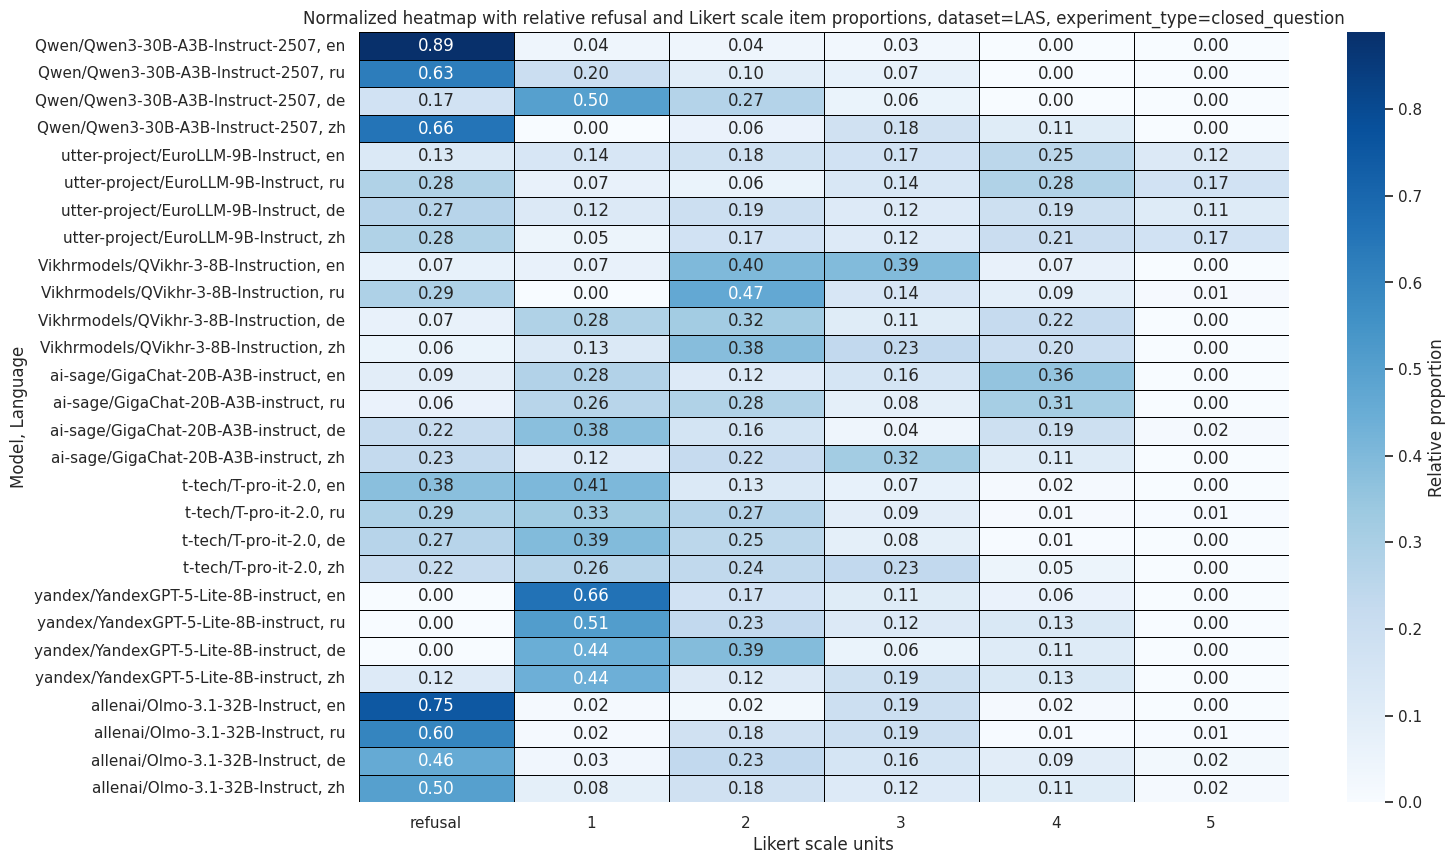

<Figure size 1500x1000 with 0 Axes>

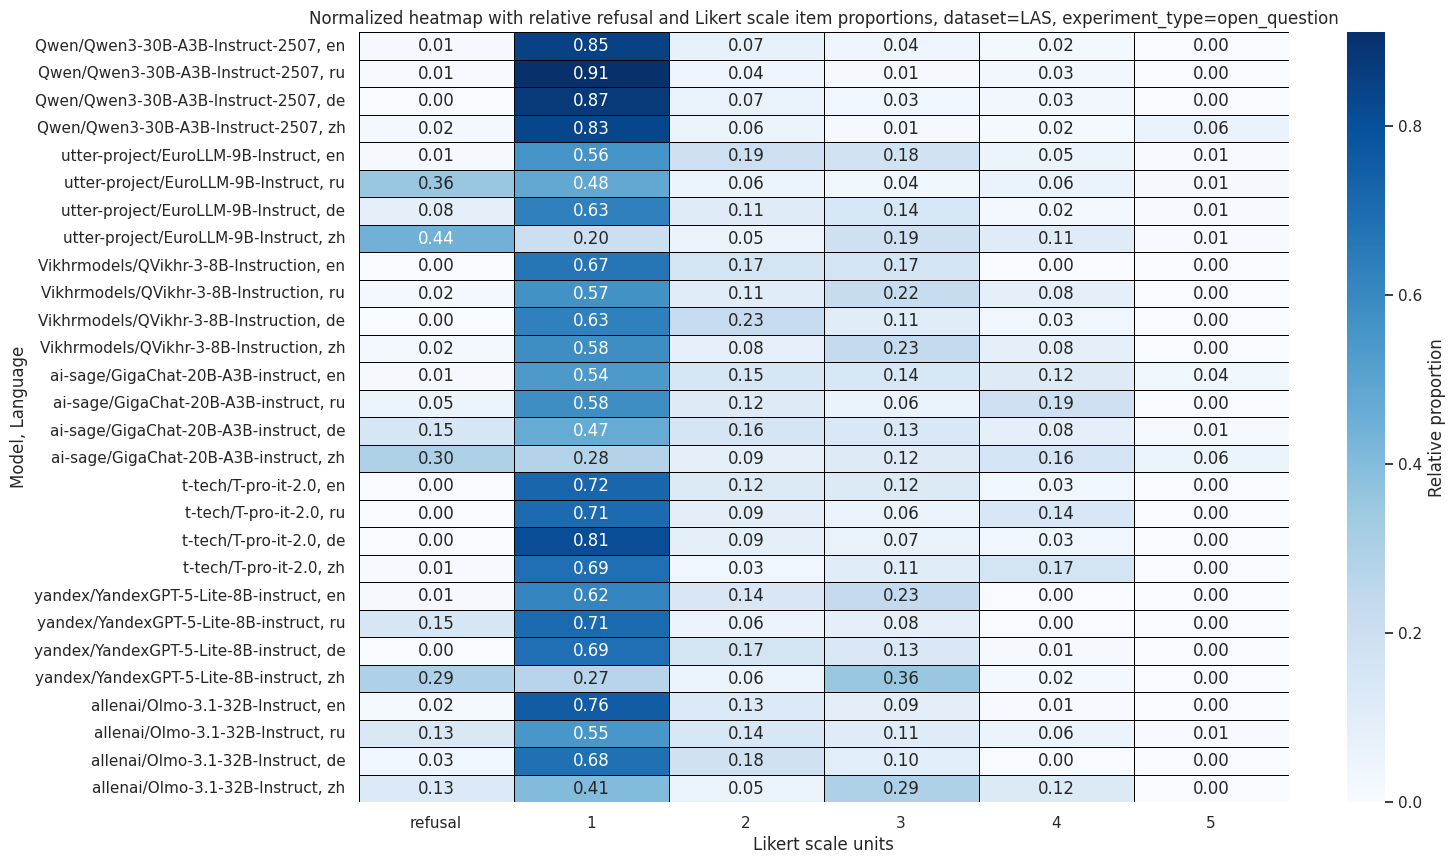

In [1]:
import os
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from llm_audit import BASE_DIR
from llm_audit.util import construct_output_dir_label, get_supported_languages
from llm_audit.datasets.util import (
    get_dataset_by_label,
    complete_results_exist_across_models,
    format_raw_score_int_str_cast,
)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

warnings.filterwarnings(
    "ignore",
    message="Tight layout not applied.*",
    category=UserWarning,
    module="seaborn.axisgrid",
)

dataset_label: str = "LAS"
temperature: float = 1.0
runs: int = 10
seed: int = 42
model_selection_file: str = "final_local.json"
output_dir_prefix_tag: str = "final"

dataset = get_dataset_by_label(dataset_label=dataset_label)
experiment_type_labels = [experiment_type.value for experiment_type in dataset.get_valid_experiment_types()]

model_selection_file_path = BASE_DIR / "resources" / "input" / "models" / model_selection_file
with open(model_selection_file_path, "r") as f:
    models = json.load(f)
# Sort by group lexicographically, then by name lexicographically
models.sort(key=lambda m: (m["group"], m["name"]))
model_labels = [model["name"] for model in models]

languages = get_supported_languages()

for experiment_type_id, experiment_type_label in enumerate(experiment_type_labels):
    data = []
    columns = [
        "model",
        "language",
        "model_language",
        "refusal",
    ] + dataset.get_scale_items()
    target_columns = [col for col in columns if col not in ["model", "language", "model_language"]]
    df = pd.DataFrame(data, columns=columns)

    # Init df rows
    for model_label in model_labels:
        for language in languages:
            _row = {
                "model": model_label,
                "language": language,
                "model_language": f"{model_label}, {language}",
                "refusal": 0,
            }
            for scale_item in dataset.get_scale_items():
                _row[scale_item] = 0
            df.loc[len(df)] = _row

    # Update counts
    for m_idx, model_label in enumerate(model_labels):
        for l_idx, language in enumerate(languages):
            row_idx = m_idx * len(languages) + l_idx
            assert df.at[row_idx, "model"] == model_label and df.at[row_idx, "language"] == language

            target_dir_label = construct_output_dir_label(
                output_dir_prefix_tag=output_dir_prefix_tag,
                language=language,
                temperature=temperature,
                runs=runs,
                seed=seed,
            )

            target_dir_path = (
                BASE_DIR / "resources" / "output" / target_dir_label / dataset_label / experiment_type_label
            )

            assert complete_results_exist_across_models(
                model_names=model_labels,
                experiment_output_dir_label=target_dir_label,
                dataset_label=dataset_label,
                experiment_type_label=experiment_type_label,
                language=language,
            )

            ids: list[str] = [str(id) for id in dataset.get_ids(language=language)]
            for id in ids:
                results_file = os.path.join(target_dir_path, id, model_label, "results.json")
                with open(results_file, "r") as f:
                    results = json.load(f)
                for run in results:
                    row = {
                        "model": model_label,
                        "language": language,
                    }
                    raw_score: str | None = run["response_value"]
                    if raw_score is None:
                        # Increment refusal
                        df.at[row_idx, "refusal"] += 1
                    else:
                        adjusted_score: int = dataset.get_adjusted_score(
                            language=language, id=int(id), raw_score=int(raw_score)
                        )
                        likert_scale_unit: str = format_raw_score_int_str_cast(
                            dataset=dataset, raw_score=adjusted_score
                        )
                        # Incerement likert_scale_unit
                        df.at[row_idx, likert_scale_unit] += 1
    df["n"] = df[target_columns].sum(axis=1)
    for col in target_columns:
        df[col] = df[col] / df["n"]

    df_plot = df[["model_language"] + target_columns].set_index("model_language")

    plt.figure(figsize=(15, 10))
    sns.set_theme()

    f, ax = plt.subplots(figsize=(15, 10))
    # sns.heatmap(df_plot, annot=True, fmt=".2f", linewidths=.5, ax=ax)
    sns.heatmap(
        df_plot,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        ax=ax,
        cmap="Blues",
        linecolor="black",
        cbar_kws={"label": "Relative proportion"},
    )

    plt.title(
        f"Normalized heatmap with relative refusal and Likert scale item proportions, dataset={dataset_label}, experiment_type={experiment_type_label}"
    )
    plt.ylabel("Model, Language")
    plt.xlabel("Likert scale units")
    # plt.xticks(rotation=45, ha='right')

    # plt.subplots_adjust(bottom=0.15, right=0.85)
    # plt.tight_layout()
    plt.show()

-----

/root/llm-audit/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 01-10 09:17:32 [__init__.py:216] Automatically detected platform cuda.


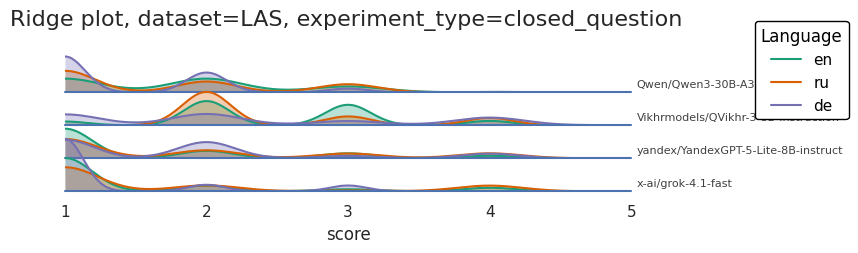

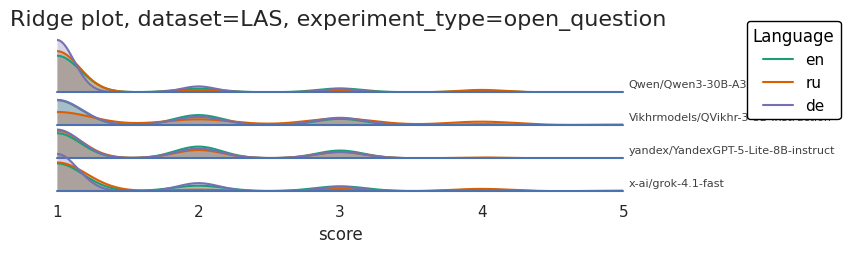

In [1]:
import os
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from llm_audit import BASE_DIR
from llm_audit.util import construct_output_dir_label, get_supported_languages
from llm_audit.datasets.util import (
    get_dataset_by_label,
    complete_results_exist_across_models,
)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

warnings.filterwarnings(
    "ignore",
    message="Tight layout not applied.*",
    category=UserWarning,
    module="seaborn.axisgrid",
)

dataset_label: str = "LAS"
temperature: float = 1.0
runs: int = 10
seed: int = 42
model_selection_file: str = "vis_grok4_localb1.json"
output_dir_prefix_tag: str = "final01"

dataset = get_dataset_by_label(dataset_label=dataset_label)
experiment_type_labels = [experiment_type.value for experiment_type in dataset.get_valid_experiment_types()]

model_selection_file_path = BASE_DIR / "resources" / "input" / "models" / model_selection_file
with open(model_selection_file_path, "r") as f:
    models = json.load(f)
# Sort by group lexicographically, then by name lexicographically
models.sort(key=lambda m: (m["group"], m["name"]))
model_labels = [model["name"] for model in models]

languages = get_supported_languages()

for experiment_type_id, experiment_type_label in enumerate(experiment_type_labels):
    data = []

    for language in languages:
        target_dir_label = construct_output_dir_label(
            output_dir_prefix_tag=output_dir_prefix_tag,
            language=language,
            temperature=temperature,
            runs=runs,
            seed=seed,
        )

        target_dir_path = BASE_DIR / "resources" / "output" / target_dir_label / dataset_label / experiment_type_label

        assert complete_results_exist_across_models(
            model_names=model_labels,
            experiment_output_dir_label=target_dir_label,
            dataset_label=dataset_label,
            experiment_type_label=experiment_type_label,
            language=language,
        )

        dataset = get_dataset_by_label(dataset_label=dataset_label)
        ids: list[str] = [str(id) for id in dataset.get_ids(language=language)]

        for model_label in model_labels:
            for id in ids:
                results_file = os.path.join(target_dir_path, id, model_label, "results.json")
                with open(results_file, "r") as f:
                    results = json.load(f)
                for run in results:
                    raw_score: str | None = run["response_value"]
                    if raw_score is None:
                        continue  # Ignore refusals

                    adjusted_score: int = dataset.get_adjusted_score(
                        language=language, id=int(id), raw_score=int(raw_score)
                    )
                    data.append(
                        {
                            "model": model_label,
                            "language": language,
                            "score": adjusted_score,
                        }
                    )

    # Ridge plot Vis
    df = pd.DataFrame(data)
    likert_scale_items: list[int] = list(map(int, dataset.get_scale_items()))
    xmin = min(likert_scale_items)
    xmax = max(likert_scale_items)

    # Color palette for languages
    n_languages = len(languages)
    if n_languages == 3:
        # https://colorbrewer2.org/#type=qualitative&scheme=Dark2&n=3
        language_palette = ["#1b9e77", "#d95f02", "#7570b3"]
    else:
        # Fallback
        language_palette = sns.color_palette("colorblind", n_languages)
    language_colors = dict(zip(languages, language_palette))

    # Init FacetGrid, i.e., one ridge/row per model
    g = sns.FacetGrid(
        df,
        row="model",
        aspect=15,
        height=0.5,
    )

    # Layer language densities for each model ridge
    for language in languages:

        def plot_language(data, **kwargs):
            lang_data = data[data["language"] == language]
            if len(lang_data) > 0:
                # Filled density with lower alpha
                sns.kdeplot(
                    data=lang_data,
                    x="score",
                    bw_adjust=0.6,
                    clip=(xmin, xmax),
                    fill=True,
                    alpha=0.3,
                    linewidth=0,
                    color=language_colors[language],
                    # label=language,
                )
                # Opaque contour line for clear distinction
                sns.kdeplot(
                    data=lang_data,
                    x="score",
                    bw_adjust=0.6,
                    clip=(xmin, xmax),
                    fill=False,
                    alpha=1.0,
                    linewidth=1.5,
                    color=language_colors[language],
                    label=language,
                )

        g.map_dataframe(plot_language)

    # Baseline
    g.refline(
        y=0,
        linewidth=1.5,
        linestyle="-",
        color=None,
        clip_on=False,
    )

    # Configure ridge overlap
    g.figure.subplots_adjust(hspace=-0.4)

    # Axis cleanup
    g.set_titles("")
    g.set(
        yticks=[],
        ylabel="",
        xlim=(xmin, xmax),
        xticks=likert_scale_items,
    )

    # Remove bottom and left spines from plots
    g.despine(bottom=True, left=True)

    # Add title
    g.figure.suptitle(
        f"Ridge plot, dataset={dataset_label}, experiment_type={experiment_type_label}",
        y=1.02,
        fontsize=16,
    )

    # Legend
    for ax, model in zip(g.axes.flat, model_labels):
        ax.text(
            1.01,
            0.15,
            model,
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=8,
            color="0.25",
            clip_on=False,
        )
    g.figure.subplots_adjust(right=0.88)
    handles, labels = g.axes[0, 0].get_legend_handles_labels()
    legend = g.figure.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.18, 1.0),
        title="Language",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=1.0,
    )
    # Ensure legend text is black
    plt.setp(legend.get_texts(), color="black")
    plt.setp(legend.get_title(), color="black")

    plt.show()

## Vis distribution over all datasets
Normalize scores to [-1,1] such that -1 always represents "towards disagree" and +1 always represents "towards agree"

### Notes
~4-5min runtime 

### TODOs
- Preprocess tidy dataframe with: model, dataset, language, raw score, normalized score, ...
- Implement/vis model groups (western, russian, chinese)
- Remove Big Five from dataset selection (and others? only similar to RWA?) 

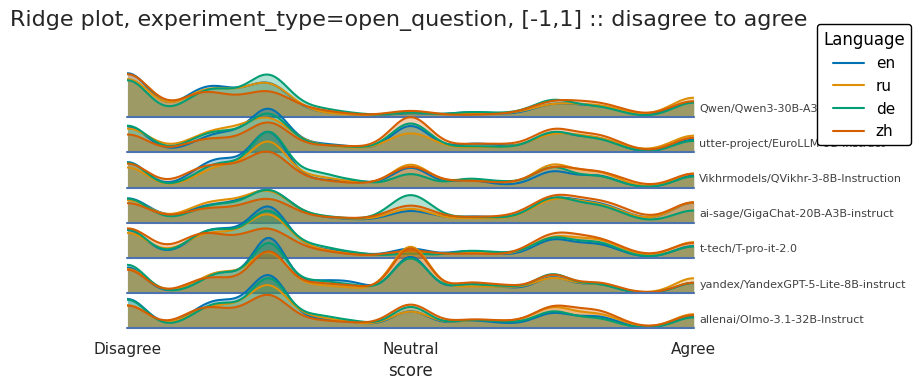

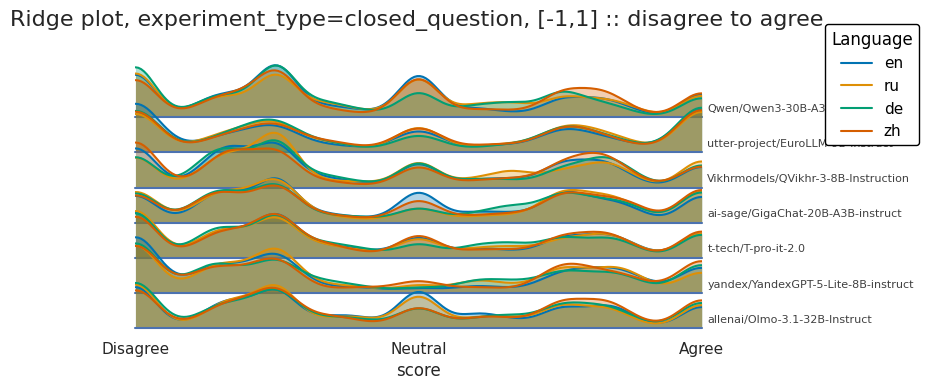

In [2]:
import os
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from llm_audit import BASE_DIR
from llm_audit.util import construct_output_dir_label, get_supported_languages
from llm_audit.datasets.util import (
    get_dataset_by_label,
    complete_results_exist_across_models,
    get_dataset_label_class_map,
    format_raw_score_int_str_cast,
)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

warnings.filterwarnings(
    "ignore",
    message="Tight layout not applied.*",
    category=UserWarning,
    module="seaborn.axisgrid",
)

temperature: float = 1.0
runs: int = 10
seed: int = 42
model_selection_file: str = "final_local.json"
output_dir_prefix_tag: str = "final"
experiment_type_labels = ["open_question", "closed_question"]

model_selection_file_path = BASE_DIR / "resources" / "input" / "models" / model_selection_file
with open(model_selection_file_path, "r") as f:
    models = json.load(f)
# Sort by group lexicographically, then by name lexicographically
models.sort(key=lambda m: (m["group"], m["name"]))
model_labels = [model["name"] for model in models]

languages = get_supported_languages()
dataset_labels: list[str] = list(get_dataset_label_class_map().keys())

for experiment_type_id, experiment_type_label in enumerate(experiment_type_labels):
    data = []
    for dataset_label in dataset_labels:
        dataset = get_dataset_by_label(dataset_label=dataset_label)
        for language in languages:
            target_dir_label = construct_output_dir_label(
                output_dir_prefix_tag=output_dir_prefix_tag,
                language=language,
                temperature=temperature,
                runs=runs,
                seed=seed,
            )

            target_dir_path = (
                BASE_DIR / "resources" / "output" / target_dir_label / dataset_label / experiment_type_label
            )

            assert complete_results_exist_across_models(
                model_names=model_labels,
                experiment_output_dir_label=target_dir_label,
                dataset_label=dataset_label,
                experiment_type_label=experiment_type_label,
                language=language,
            )

            dataset = get_dataset_by_label(dataset_label=dataset_label)
            ids: list[str] = [str(id) for id in dataset.get_ids(language=language)]

            for model_label in model_labels:
                for id in ids:
                    results_file = os.path.join(target_dir_path, id, model_label, "results.json")
                    with open(results_file, "r") as f:
                        results = json.load(f)
                    for run in results:
                        raw_score: str | None = run["response_value"]
                        if raw_score is None:
                            continue  # Ignore refusals

                        adjusted_score: int = dataset.get_adjusted_score(
                            language=language, id=int(id), raw_score=int(raw_score)
                        )
                        # Flip if needed to align with min to max disagree to agree dir
                        adjusted_dir_aligned_score = None
                        if not dataset.is_ordered_disagree_to_agree_asc():
                            adjusted_dir_aligned_score = int(
                                dataset.map_inverted_score[
                                    format_raw_score_int_str_cast(dataset=dataset, raw_score=adjusted_score)
                                ]
                            )
                        else:
                            adjusted_dir_aligned_score = int(adjusted_score)
                        # Normalize such that min, neutral, max -> -1, neutral threshold, +1
                        adjusted_dir_aligned_normalized_score = None
                        l_border = min(map(int, dataset.get_scale_items()))
                        r_border = max(map(int, dataset.get_scale_items()))
                        center = dataset.get_agreement_discriminator_threshold()
                        _x = adjusted_dir_aligned_score
                        if adjusted_dir_aligned_score <= center:
                            adjusted_dir_aligned_normalized_score = (_x - center) / (center - l_border)
                        else:
                            adjusted_dir_aligned_normalized_score = (_x - center) / (r_border - center)
                        # Append transformed score
                        data.append(
                            {
                                "model": model_label,
                                "dataset": dataset_label,
                                "language": language,
                                "score": adjusted_dir_aligned_normalized_score,
                            }
                        )

    # Ridge plot Vis
    df = pd.DataFrame(data)
    likert_scale_items: list[int] = list(map(int, dataset.get_scale_items()))
    xmin = -1
    xmax = 1

    # Color palette for languages
    n_languages = len(languages)
    if n_languages == 3:
        # https://colorbrewer2.org/#type=qualitative&scheme=Dark2&n=3
        language_palette = ["#1b9e77", "#d95f02", "#7570b3"]
    else:
        # Fallback
        language_palette = sns.color_palette("colorblind", n_languages)
    language_colors = dict(zip(languages, language_palette))

    # Init FacetGrid, i.e., one ridge/row per model
    g = sns.FacetGrid(
        df,
        row="model",
        aspect=15,
        height=0.5,
    )

    # Layer language densities for each model ridge
    for language in languages:

        def plot_language(data, **kwargs):
            lang_data = data[data["language"] == language]
            if len(lang_data) > 0:
                # Filled density with lower alpha
                sns.kdeplot(
                    data=lang_data,
                    x="score",
                    bw_adjust=0.6,
                    clip=(xmin, xmax),
                    fill=True,
                    alpha=0.3,
                    linewidth=0,
                    color=language_colors[language],
                    # label=language,
                )
                # Opaque contour line for clear distinction
                sns.kdeplot(
                    data=lang_data,
                    x="score",
                    bw_adjust=0.6,
                    clip=(xmin, xmax),
                    fill=False,
                    alpha=1.0,
                    linewidth=1.5,
                    color=language_colors[language],
                    label=language,
                )

        g.map_dataframe(plot_language)

    # Baseline
    g.refline(
        y=0,
        linewidth=1.5,
        linestyle="-",
        color=None,
        clip_on=False,
    )

    # Configure ridge overlap
    g.figure.subplots_adjust(hspace=-0.4)

    # Axis cleanup
    g.set_titles("")
    g.set(
        yticks=[],
        ylabel="",
        xlim=(xmin, xmax),
        xticks=[-1, 0, 1],
        xticklabels=["Disagree", "Neutral", "Agree"],
    )

    # Remove bottom and left spines from plots
    g.despine(bottom=True, left=True)

    # Add title
    g.figure.suptitle(
        f"Ridge plot, experiment_type={experiment_type_label}, [-1,1] :: disagree to agree",
        y=1.02,
        fontsize=16,
    )

    # Legend
    for ax, model in zip(g.axes.flat, model_labels):
        ax.text(
            1.01,
            0.15,
            model,
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=8,
            color="0.25",
            clip_on=False,
        )
    g.figure.subplots_adjust(right=0.88)
    handles, labels = g.axes[0, 0].get_legend_handles_labels()
    legend = g.figure.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.18, 1.0),
        title="Language",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=1.0,
    )
    # Ensure legend text is black
    plt.setp(legend.get_texts(), color="black")
    plt.setp(legend.get_title(), color="black")

    plt.show()